In [1]:
pip install tensorflow keras pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Epoch 1/50


C:\Users\VEDANG\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 169.0474 - mae: 9.4878 - val_loss: 87.8871 - val_mae: 7.4779
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 69.8862 - mae: 6.0255 - val_loss: 60.3484 - val_mae: 5.8752
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 62.1491 - mae: 5.6553 - val_loss: 51.8538 - val_mae: 5.0409
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 70.4495 - mae: 6.2179 - val_loss: 65.0885 - val_mae: 5.3327
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 55.9211 - mae: 5.5896 - val_loss: 45.5710 - val_mae: 5.3974
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 48.2522 - mae: 4.9225 - val_loss: 41.7540 - val_mae: 5.0593
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 55.1542 - mae: 5.4374 - val_loss: 49.0697 - val_mae: 5.9796
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 47.5246 - mae: 4.9842 - val_loss: 37.7677 - val_mae: 4.1261
Epoch 9/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 59.9459 

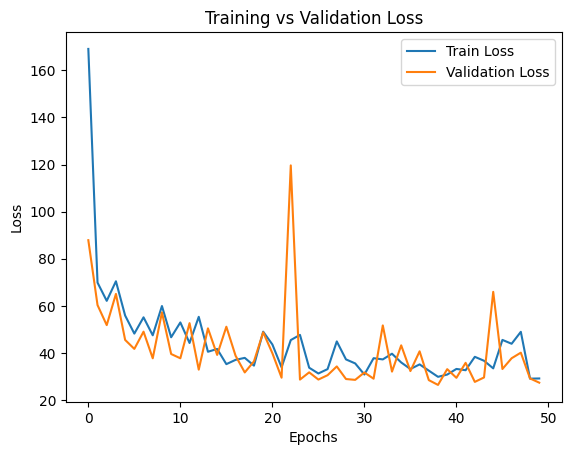

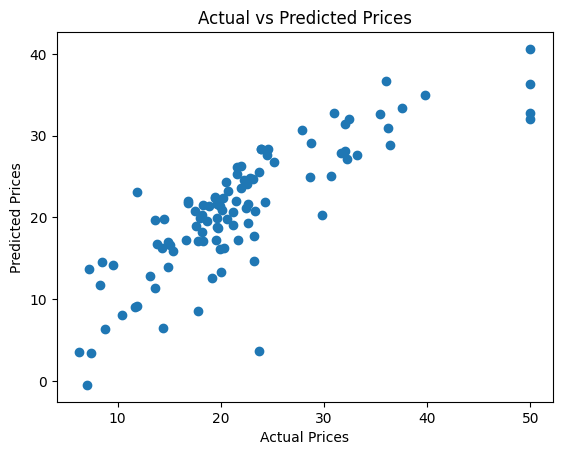

In [5]:
# Step 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Step 2: Load dataset from local file
data = pd.read_csv("boston.csv")

# Features and target
X = data.drop("MEDV", axis=1)   # MEDV = house price
y = data["MEDV"]

# Step 3: Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Step 4: Model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

# Step 5: Compile
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Step 6: Train (IMPORTANT: validation_data added)
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=8,
                    validation_split=0.2)

# Step 7: Evaluate
loss, mae = model.evaluate(X_test, y_test)
print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

# Step 8: Predictions
y_pred = model.predict(X_test)

# -------------------------------
# 📊 PLOT 1: Training vs Validation Loss
# -------------------------------
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

# -------------------------------
# 📊 PLOT 2: Actual vs Predicted
# -------------------------------
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()